In [1]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
print(cancer.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [2]:
import pandas as pd
df=pd.DataFrame(cancer.data,
                columns=cancer.feature_names)
df['Target'] = cancer.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames, retaining column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Also scale the full X dataset for cross-validation
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [5]:
from sklearn.model_selection import KFold,cross_val_score
kf = KFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X,
    y,
    cv=kf
)

scores

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

array([0.95614035, 0.97368421, 0.9122807 , 0.96491228, 0.92035398])

In [6]:
print("Mean Accuracy:",scores.mean())

Mean Accuracy: 0.9454743052321067


In [7]:
print("Standard Deviation:",scores.std())

Standard Deviation: 0.0245774047156121


In [8]:
from sklearn.model_selection import KFold,cross_val_score
scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X,
    y,
    cv=5
)

scores

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

array([0.93859649, 0.93859649, 0.97368421, 0.94736842, 0.96460177])

In [9]:
print("Mean Accuracy:",scores.mean())

Mean Accuracy: 0.9525694767893185


In [10]:
print("Standard Deviation:",scores.std())

Standard Deviation: 0.014199631617252084


Evaluating Logistic Regression with Stratified K-Fold Cross-Validation for n_splits from 2 to 10:

n_splits = 2: Mean Accuracy = 0.9368
n_splits = 3: Mean Accuracy = 0.9508
n_splits = 4: Mean Accuracy = 0.9490
n_splits = 5: Mean Accuracy = 0.9508
n_splits = 6: Mean Accuracy = 0.9508
n_splits = 7: Mean Accuracy = 0.9525
n_splits = 8: Mean Accuracy = 0.9525
n_splits = 9: Mean Accuracy = 0.9490
n_splits = 10: Mean Accuracy = 0.9526


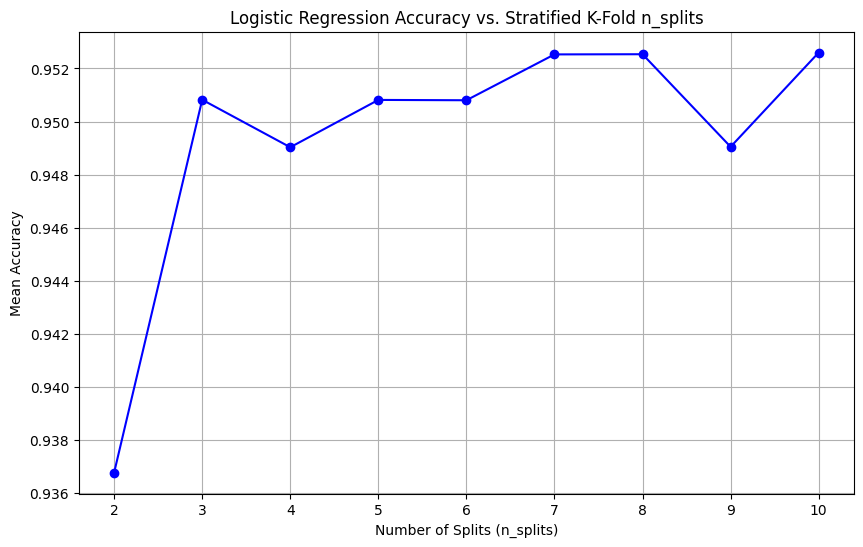

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Define X and y to ensure they are available in this cell's scope
X = df.drop('Target', axis=1)
y = df['Target']

accuracy_scores = []
n_splits_values = range(2, 11)

print("Evaluating Logistic Regression with Stratified K-Fold Cross-Validation for n_splits from 2 to 10:\n")

for n_s in n_splits_values:
    # Ensure n_splits is not greater than the number of samples
    if n_s > len(X):
        print(f"Skipping n_splits = {n_s} as it's greater than the number of samples ({len(X)}).")
        accuracy_scores.append(0) # Append 0 or None for skipped values if needed for plotting
        continue

    kf = StratifiedKFold(n_splits=n_s, shuffle=True, random_state=42)
    scores = cross_val_score(
        LogisticRegression(max_iter=1000, solver='liblinear'), # Using 'liblinear' solver for better convergence with default settings
        X, # X is the feature set
        y, # y is the target variable, required for StratifiedKFold
        cv=kf
    )
    mean_accuracy = scores.mean()
    accuracy_scores.append(mean_accuracy)
    print(f"n_splits = {n_s}: Mean Accuracy = {mean_accuracy:.4f}")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(n_splits_values, accuracy_scores, marker='o', linestyle='-', color='blue')
plt.title('Logistic Regression Accuracy vs. Stratified K-Fold n_splits')
plt.xlabel('Number of Splits (n_splits)')
plt.ylabel('Mean Accuracy')
plt.xticks(list(n_splits_values))
plt.grid(True)
plt.show()

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42), # Added random_state
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42), # Added random_state
    "Random Forest": RandomForestClassifier(random_state=42), # Added random_state
    "Support Vector Machine": SVC(random_state=42) # Added random_state
}

results = []

In [13]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Initialize StratifiedKFold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # All models will use X_scaled for cross-validation
    scores = cross_val_score(model, X_scaled, y, cv=kf)

    mean_accuracy = scores.mean()
    std_accuracy = scores.std()
    results.append({
        'Model': name,
        'Mean Accuracy': mean_accuracy,
        'Std Dev Accuracy': std_accuracy
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Mean Accuracy', ascending=False)

print("\nCross-Validation Results:")
display(results_df)


Cross-Validation Results:


,Model,Mean Accuracy,Std Dev Accuracy
4,Support Vector Machine,0.975408,0.019525
0,Logistic Regression,0.973669,0.016627
1,K-Nearest Neighbors,0.966605,0.014043
3,Random Forest,0.956094,0.012340
2,Decision Tree,0.910402,0.027876


/tmp/ipykernel_846/862025713.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Mean Accuracy', data=results_df, palette='viridis')


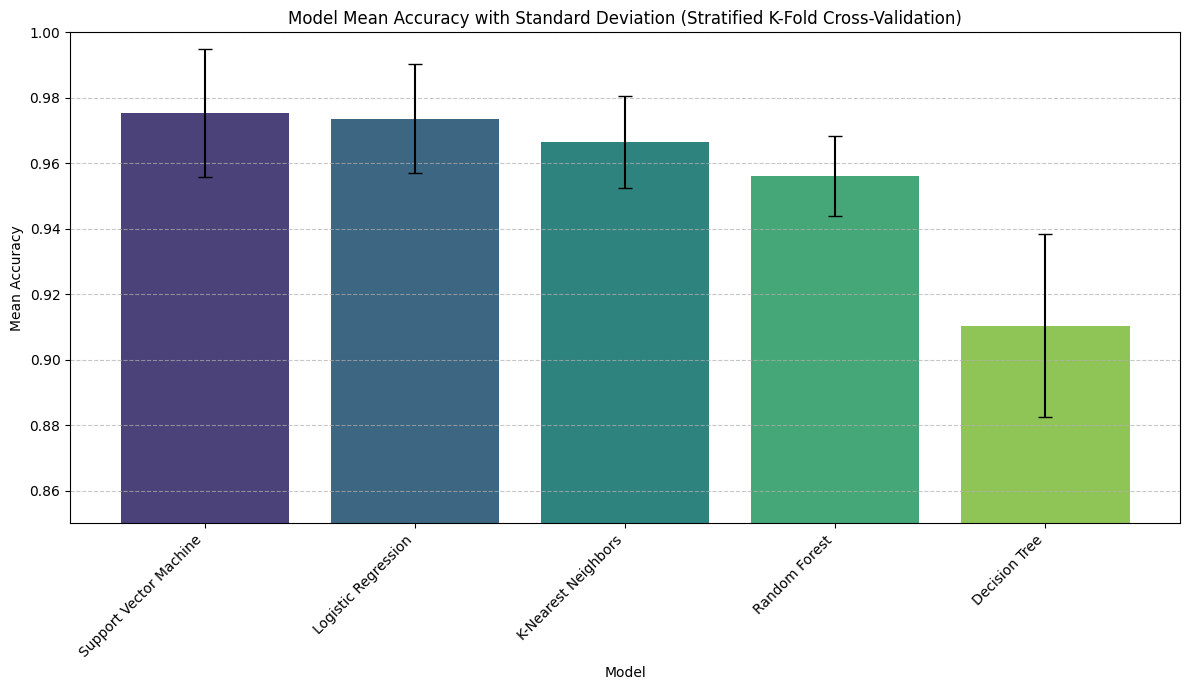

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Mean Accuracy', data=results_df, palette='viridis')
plt.errorbar(x=results_df['Model'], y=results_df['Mean Accuracy'], yerr=results_df['Std Dev Accuracy'], fmt='none', c='black', capsize=5)
plt.title('Model Mean Accuracy with Standard Deviation (Stratified K-Fold Cross-Validation)')
plt.xlabel('Model')
plt.ylabel('Mean Accuracy')
plt.ylim(0.85, 1.0) # Set a reasonable y-axis limit
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': [0.001,0.01,0.1,1]
}

param_grid

{'C': [0.1, 1, 10, 100],
 'kernel': ['linear', 'rbf'],
 'gamma': [0.001, 0.01, 0.1, 1]}

In [16]:
grid = GridSearchCV(
    estimator=SVC(probability=True),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')